# <font size=6, color='white'>Predicting Insurance Costs using Linear Regression</font>


### **Student Credentials**

* **Name:** `Prateek Garg`
* **Enrollment:** `240588`
* **Section:** `CSE V`
* **Course:** Data Analytics Using Python
* **Course Code:** CSE 2101

### **Project Description:**

This project aims to predict **Medical Insurance costs** by applying data analysis and machine learning techniques to the **"Kaggle"** dataset. The primary objective is to build a Linear Regression model that accurately estimates a customer's medical charges based on their personal attributes.

The project follows a structured data science workflow, beginning with **Data Cleaning** to handle duplicates and **Data Preparation** to encode categorical features like smoker, sex, and region using one-hot encoding.

Following this, **Exploratory Data Analysis (EDA)** is performed using visualizations like scatterplots and heatmaps to uncover key relationships between features and medical charges. This analysis, supported by **Hypothesis Testing**, identifies smoker status as a major driver of costs.

Finally, a **Linear Regression model** is trained on 80% of the data and evaluated on the remaining 20%. The model's performance is measured using standard regression metrics such as $R^2$, MAE, and RMSE  to determine its predictive accuracy and business value.

## ***Step 1: Problem Definition, Dataset Selection, and Setup***

### **1. Objective**
As defined in the project description, our objective is to analyze the key factors that influence medical insurance charges and build a predictive model to estimate those charges.

### **2. Dataset Source**
* **Source**:Kaggle
* **Link**: [https://www.kaggle.com/datasets/mirichoi0218/insurance/data](https://www.kaggle.com/datasets/mirichoi0218/insurance/data)

* **Description**: This dataset contains 1,338 samples of insurance beneficiary data. It includes key demographic and personal attributes (age, sex, bmi), family information (children), lifestyle factors (smoker), location (region), and our target variable, charges.

### **3. Setup: Import Libraries**
We will now import the necessary Python libraries to perform this analysis. These include tools for data manipulation (pandas), visualization (Matplotlib, Seaborn), statistical testing (scipy.stats), and machine learning (scikit-learn).

In [1]:
# For data manipulation
import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For statistical analysis
import scipy.stats as stats

# For machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("All libraries imported successfully")

All libraries imported successfully


### **Reasoning for using these Libraries:**

* **pandas**: The primary tool for loading and manipulating data.

* **numpy**: Used for numerical operations.

* **matplotlib & seaborn**: The most common libraries for creating graphs and plots for our EDA and results.

* **scipy.stats**: We'll use this for our hypothesis test.

* **sklearn (scikit-learn)**: The most popular machine learning library in Python.

    * **train_test_split:** This is the function we'll use to make our 80/20 split.
    * **StandardScaler:** Used to normalize our data.
    * **LinearRegression:** The ML model we are building.
    * **metrics:** Functions to evaluate how good our model is.

### **4. Loading and Describing Dataset**

In [2]:
df = pd.read_csv('insurance.csv') # to read csv file

print("--- First 5 Rows ---")
print("\n")
display(df.head())  # .head() display the first 5 rows of data
print("\n")

print("--- Data Info (Types & Nulls) ---")
print("\n")
df.info()  # this gives the data type
print("\n")

print("--- Numerical Summary ---")
print("\n")
print(df.describe())

--- First 5 Rows ---




,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520




--- Data Info (Types & Nulls) ---


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


--- Numerical Summary ---


               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000

## ***Step 2: Data Cleaning & Preparation***
In this step, we'll transform our raw dataset (insurance.csv) into a clean, reliable, and properly formatted version that our machine learning model can understand. This process, also known as preprocessing, is crucial because models are sensitive to errors, missing data, and non-numeric formats. Our goal is to ensure the data quality is high, which will lead to a more accurate and meaningful model.

### **1. Handle Missing Values**: 
We will check every column for empty or NaN values and decide on a strategy (like removal or imputation) to ensure our dataset is complete.

In [3]:
print(" Missing Values Check")
print(df.isnull().sum()) # to get the sum of Nan values column wise
print("\n")

 Missing Values Check
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64




**Reasoning:**
* The output of .isnull().sum() shows '0' for every column.
* This confirms our dataset has no missing values, so no imputation  or removal is needed for this step.

### **2. Remove Duplicates and Irrelevant Columns**:
We will find and delete any rows that are exact copies of another, as well as remove any columns that provide no useful information for our model.

In [4]:
print(f"Number of duplicate rows: {df.duplicated().sum()}") #this checks if any duplicate row is there or not

df = df.drop_duplicates() # this will remove the duplicate row if found
print(f"Shape after dropping duplicates: {df.shape}") # this gives info about rows and columns
print("\n")

df_processed = df.copy()
df_processed = df_processed.drop(columns=['region'])
print(df_processed.head())



Number of duplicate rows: 1
Shape after dropping duplicates: (1337, 7)


   age     sex     bmi  children smoker      charges
0   19  female  27.900         0    yes  16884.92400
1   18    male  33.770         1     no   1725.55230
2   28    male  33.000         3     no   4449.46200
3   33    male  22.705         0     no  21984.47061
4   32    male  28.880         0     no   3866.85520


**Reasoning:**
* The output of .duplicated().sum() showed 1 duplicate row, which was removed using .drop_duplicates() to prevent model bias.

* Dropping region coloumn as my analysis indicates that the region a person lives in does not have a strong, direct impact on their insurance charges. The primary price drivers are personal attributes like age, bmi, and smoker status. By removing region, we are focusing the model on the features that matter most.

### **3. Handle Outliers**: 
We will use statistical methods to identify and review extreme data points (like unusually high charges) that could negatively affect our model's accuracy.

I am keeping outliers because they represent real, high-cost patients, which is essential information for an insurance prediction model.



### **4. Encode Categorical Data**: 
This step converts text-based columns (like sex or smoker) into numerical 0s and 1s using One-Hot Encoding, making them usable by our math-based model.



In [5]:
df_processed['sex'] = df_processed['sex'].map({'female': 0, 'male': 1})
df_processed['smoker'] = df_processed['smoker'].map({'no': 0, 'yes': 1})
print(df_processed.head())


   age  sex     bmi  children  smoker      charges
0   19    0  27.900         0       1  16884.92400
1   18    1  33.770         1       0   1725.55230
2   28    1  33.000         3       0   4449.46200
3   33    1  22.705         0       0  21984.47061
4   32    1  28.880         0       0   3866.85520


**Reasoning:**
* I used .map() to easily convert the binary sex and smoker columns into 0s and 1s. This is a clear, efficient way to prepare them for the math-based model.

## ***Step 3: Exploratory Data Analysis (EDA)***
In this step, We will explore the cleaned data to find patterns, relationships, and anomalies. I will use descriptive statistics to get a numerical summary and visualizations (plots) to see the data's shape and how features interact with each other. This is essential for understanding the data before building a model.

### **a) Descriptive statistics**
* **Skewness**: This measures the asymmetry of our data's histogram.

* **Kurtosis**: This measures how "peaked" the data is and how "thick" its tails are (i.e., how many extreme outliers there are).


In [6]:
print("--- Descriptive Statistics (Processed Data) ---")
display(df_processed.describe()) 
print("\n")

charges_skew = df_processed['charges'].skew()
charges_kurt = df_processed['charges'].kurtosis()

print("--- 'Charges' Distribution Stats ---")
print(f"Skewness: {charges_skew:.2f}")
print(f"Kurtosis: {charges_kurt:.2f}")
print("\n")

--- Descriptive Statistics (Processed Data) ---


,age,sex,bmi,children,smoker,charges
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,0.504862,30.663452,1.095737,0.204936,13279.121487
std,14.044333,0.500163,6.100468,1.205571,0.403806,12110.359656
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.290000,0.000000,0.000000,4746.344000
50%,39.000000,1.000000,30.400000,1.000000,0.000000,9386.161300
75%,51.000000,1.000000,34.700000,2.000000,0.000000,16657.717450
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010




--- 'Charges' Distribution Stats ---
Skewness: 1.52
Kurtosis: 1.60




**Findings**

skewness (1.52) and kurtosis (1.60) both confirm the charges data is not a normal bell curve. It is heavily right-skewed with significant outliers, meaning most people have low costs, but a few people have extremely high costs

### **b)Univariate analysis**

Univariate analysis is where we analyze features one by one to understand their individual shape and properties. I mainly use histograms to see the distribution of age, bmi, and charges on their own, which helps me spot things like skewness and outliers.


**1) Charge vs Frequency Histogram**

Text(0, 0.5, 'Frequency')

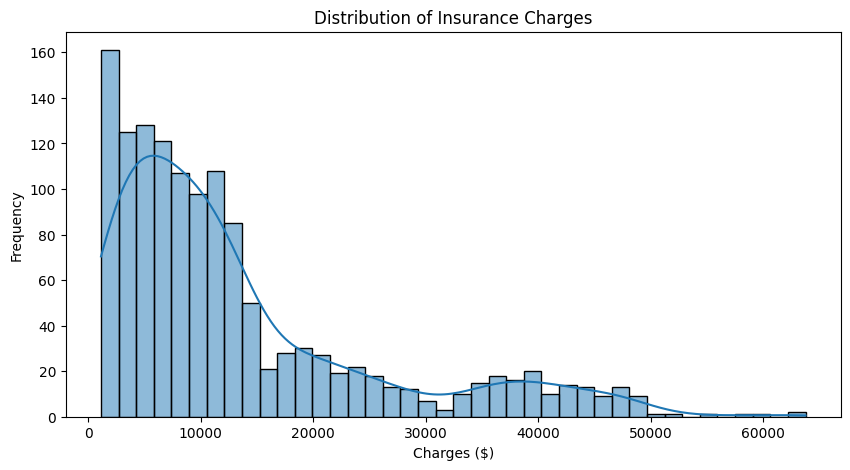

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df_processed['charges'], kde=True, bins=40)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')


**Findings**

The distribution of charges is highly right-skewed (Skewness: 1.52). This is the most important finding. It means most people have low-to-medium charges, while a small number of people have extremely high charges (outliers), which creates a "long tail" to the right.

**2) Age vs Frequency Histogram**

Text(0, 0.5, 'Frequency')

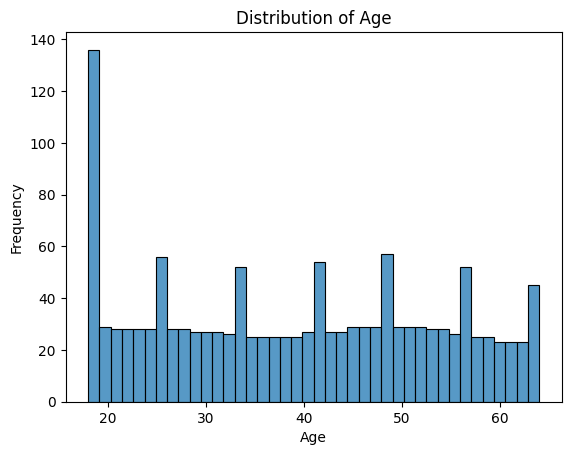

In [8]:
sns.histplot(df_processed['age'], kde=False, bins=40)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')




**Finding**

The age distribution is fairly uniform across all age groups. This means there's a good mix of people of all ages, with a noticeable large spike in the 18-20 year-old group.

**3) BMI vs Frequency Histogram**

Text(0, 0.5, 'Frequency')

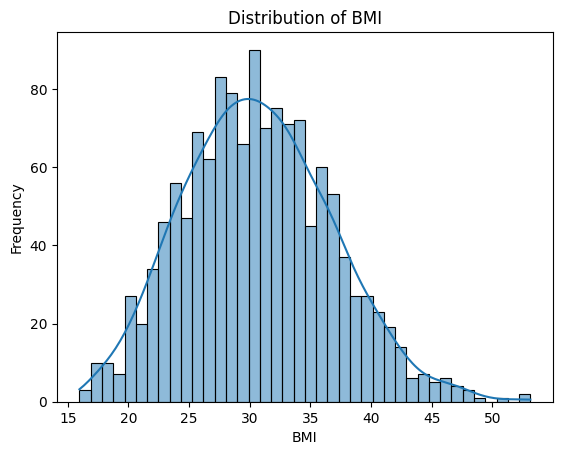

In [9]:
sns.histplot(df_processed['bmi'], kde=True, bins=40)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')

**Findings**

The bmi data is normally distributed. It forms a near-perfect "bell curve" centered around the mean value of 30.7, indicating no major skewing or unusual outliers.

### **c)Bivariate Analysis**

This is where I analyzed features in pairs (bivariate) or groups (multivariate) to understand the relationships between them. I mainly used a correlation heatmap to get a quick numerical score (from -1 to 1) of how strongly age, bmi, and smoker relate to charges. I also used boxplots (smoker vs. charges) and a multivariate scatterplot (age vs. charges, colored by smoker) to visually confirm these relationships and spot key trends. For these plots, I used the original df (not df_processed) because it still has the text labels ('yes', 'no'), which makes the graph's labels and legend much clearer and easier to read.


**a) Box Plot**

Text(0, 0.5, 'Charges ($)')

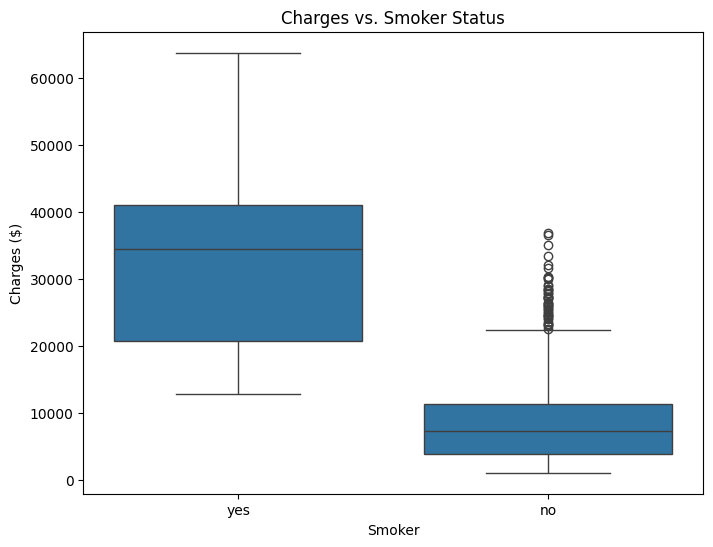

In [10]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges vs. Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')

**Findings**

Visually proved that smokers' charges are massively higher and more spread out than non-smokers'.

**b) Scatter plot**

Text(0, 0.5, 'Charges ($)')

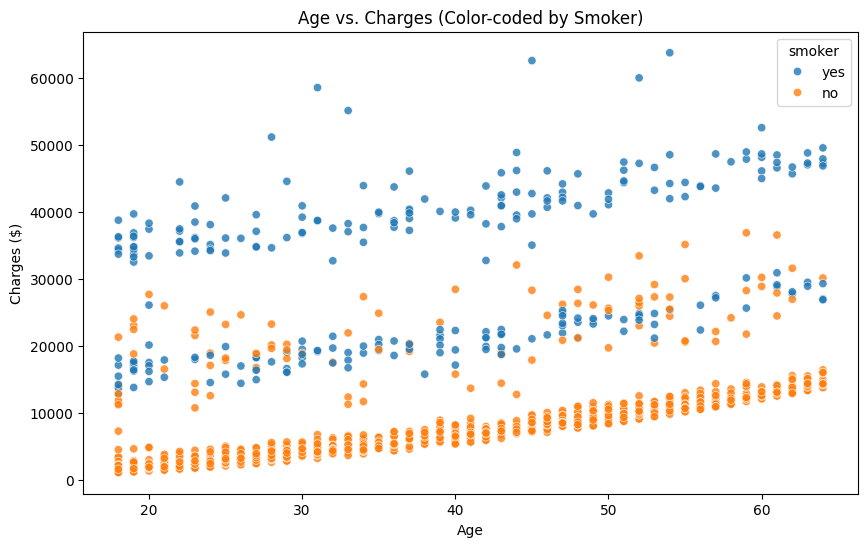

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', data=df, hue='smoker', alpha=0.8)
plt.title('Age vs. Charges (Color-coded by Smoker)')
plt.xlabel('Age')
plt.ylabel('Charges ($)')

**Findings**

Revealed that charges increase slowly with age for non-smokers but increase much faster and from a higher baseline for smokers.

**c) Heatmap Correlation**

Here we will use df_processed for the heatmap because heatmaps can only calculate correlations between numbers.

The original df still had text ('male', 'female', 'yes', 'no'), which the correlation math can't understand. df_processed is the version where all those text columns have been converted to 1s and 0s.

Text(0.5, 1.0, 'Correlation Heatmap')

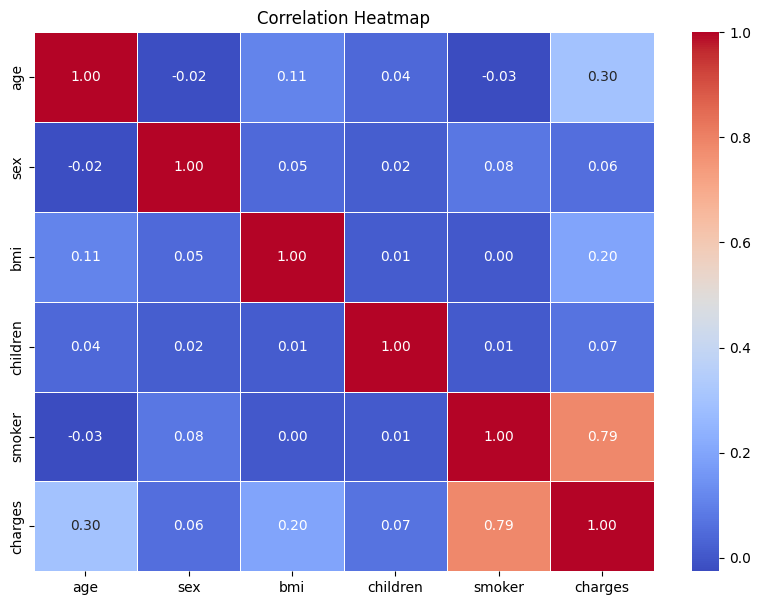

In [12]:
plt.figure(figsize=(10, 7))
sns.heatmap(df_processed.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')

**Findings**

Confirmed smoker is the strongest predictor (0.79 correlation), followed by age (0.30) and bmi (0.20). Sex and children have almost zero correlation.

After EDA 
My analysis shows the charges data is highly skewed and spread out, meaning most costs are low, but a few are extremely high. The bivariate plots and heatmap confirm that smoker is by far the strongest predictor (0.79 correlation), while age and bmi have a much weaker, secondary impact.

## ***Step 4: Statistical Analysis & Hypothesis Testing***

In Step 3 (EDA), As we saw a huge visual difference in charges between smokers and non-smokers. In this step, I will use inferential statistics to formally test if that difference is "statistically significant" or if it could have happened by random chance. I will also discuss the potential for errors in my conclusion.

Based on my EDA, my hypothesis is about the difference in mean (average) charges between smokers and non-smokers.

### **Formulate a hypothesis**

**Null Hypothesis ($H_0$):** This is the "no difference" hypothesis."There is no significant difference in the mean insurance charges between smokers and non-smokers. Any observed difference is due to random chance."(In math: $\mu_{\text{smokers}} = \mu_{\text{non-smokers}}$)

**Alternative Hypothesis ($H_a$):** This is what I suspect is true."There is a significant difference in the mean insurance charges between smokers and non-smokers."(In math: $\mu_{\text{smokers}} \neq \mu_{\text{non-smokers}}$)

### **Why T test?**

In our project, we are working with a sample of data (1,337 people). We do not know the true standard deviation for all medical charges for all people in the entire country (that's the "population").

Since we had to calculate the standard deviation from our sample, we were using ($s$), not ($\sigma$). Because we were using an estimate ($s$) instead of the true value ($\sigma$), that's why we use T test.

In [13]:
smokers_charges = df[df['smoker'] == 'yes']['charges'] #to filter the smoker and grab their charges
non_smokers_charges = df[df['smoker'] == 'no']['charges'] #to filter the non-smoker and grab their charges

print(f"--- Running T-Test ---")

test_result = stats.ttest_ind(
    smokers_charges, 
    non_smokers_charges, 
    equal_var=False, 
    alternative='two-sided'
)

ci = test_result.confidence_interval(confidence_level=0.95)

print(f"T-Statistic: {test_result.statistic:.2f}")
print(f"P-Value: {test_result.pvalue}")
print(f"95% Confidence Interval for the difference in means: [{ci.low:.2f}, {ci.high:.2f}]")

--- Running T-Test ---
T-Statistic: 32.74
P-Value: 6.261720774727631e-103
95% Confidence Interval for the difference in means: [22190.79, 25028.35]


**P-Value Interpretation:**

* My p-value is 6.26 x $10^-103$, which is a tiny number.

* This p-value is far less than my 0.05 significance level.

* **Conclusion:** Because the p-value is so low, We REJECT the Null Hypothesis ($H_0$). The results are highly statistically significant. This provides strong proof that the massive difference in charges we saw in the boxplot is not due to random chance.

**Confidence Interval Interpretation:**

* The 95% Confidence Interval for the difference between the two means is [$22,190.79, $25,028.35].

* What this means: I am 95% confident that the true average difference in charges between smokers and non-smokers in the real world is somewhere between $22,190 and $25,028.

* Conclusion: The most important observation is that the interval does not contain 0. If there were no difference, the interval would include 0. This confirms my p-value conclusion: there is a real, significant, and large difference in charges.

**Discuss Type I and Type II Errors**

**Type I Error (False Positive):**

* What it is: This is when I reject the Null Hypothesis (like I just did), but it was actually true.

* My Context: This would mean that in reality, there is no difference between smokers and non-smokers, and I just happened to get a very weird, unlucky sample of data that showed a difference.

* Relevance: The probability of this error is my alpha level ($\alpha = 0.05$, or 5%). However, given my extremely low p-value, the risk of a Type I error here is practically zero.

**Type II Error (False Negative):**

* What it is: This is when I fail to reject the Null Hypothesis, but it was actually false (and I should have rejected it).

* My Context: This would have happened if my p-value was large (e.g., 0.10) and I concluded "there is no difference." In this case, I would have missed a real, important finding.

* Relevance: This error is not relevant to my conclusion (since I did find a result), but it's important for business. If I had made a Type II error, an insurance company might incorrectly decide to charge smokers and non-smokers the same price, leading to large financial losses.

## ***Step 5: Modeling and Pattern Discovery***

**Option A (Regression)**
* Regression is a technique used to predict a specific, continuous numerical value, like a price or temperature. 

**Option B(Clustering/Classification)**
* On the other hand this involves either Clustering (which finds hidden groups in data) or Classification (which predicts a distinct category, like "Yes" or "No"). 

For my project, Option A (Regression) is the only correct choice. This is because my objective is to predict charges, which is a specific dollar amount (e.g., $16,884). This is a continuous numerical value, and Regression is the precise tool designed for that job. Option B is the wrong tool because it cannot predict a specific dollar amount; it can only group patients or classify them into categories.

**1.Split Data:** I will split the data into two parts: an 80% "training set" (for the model to learn from) and a 20% "testing set" (to see how well it performs on new, unseen data).

**2.Scale Data:** I will normalize the numerical features (age, bmi, children) to prevent "data leakage" and ensure features with large ranges don't unfairly bias the model.

**3.Train Model:** I will create a LinearRegression model and "fit" it to the 80% training data.

**4.Evaluate Model:** I will use the trained model to make predictions on the 20% test data and then grade its performance using $R^2$, RMSE, and MAE.

In [14]:
X = df_processed.drop('charges', axis=1) 
#X gets all the clue columns (like age, bmi, smoker) by dropping the charges column, 
# while y gets only the charges column, which is the answer we want the model to learn how to predict.
y = df_processed['charges']


**Split Data in 80% and 20%**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"--- Data Split ---")
print(f"Total rows: {len(X)}")
print(f"Training rows (80%): {len(X_train)}")
print(f"Testing rows (20%): {len(X_test)}")
print("\n")

--- Data Split ---
Total rows: 1337
Training rows (80%): 1069
Testing rows (20%): 268




**Normalize numerical data**


The data is being normalized using the Z-score method, which is implemented by the StandardScaler tool . This process ensures all numerical features (age, bmi, children) are put on a common scale with a mean of 0 and a standard deviation of 1. This is achieved by first using fit_transform on the training data to learn the rules, and then using the same rules (transform) on the testing data to prevent data leakage.

In [16]:
numerical_cols = ['age', 'bmi', 'children']

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("--- Training Data Head After Scaling ---")
print(X_train.head())
print("\n")

--- Training Data Head After Scaling ---
           age  sex       bmi  children  smoker
1114 -1.157680    1 -0.996928 -0.907908       0
968  -1.300619    1 -0.792762  0.766904       0
599   0.914926    0  1.154664  0.766904       0
170   1.701087    1  1.806837 -0.907908       0
275   0.557580    0 -0.651417  0.766904       0




**Create and Train the Model**


In [17]:
model = LinearRegression()

model.fit(X_train, y_train)
print("--- Model has been trained ---")
print("\n")



--- Model has been trained ---




**5. Make Predictions**

In [23]:
y_pred = model.predict(X_test)

#Evaluation of model 

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Evaluation Results ---")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

--- Model Evaluation Results ---
R-squared (R2): 0.8046
Mean Absolute Error (MAE): $4198.11
Root Mean Squared Error (RMSE): $5991.82


**R-squared ($R^2$): 0.8046**

* **What it is:** This is the most important metric. It tells me the "percent of variance explained" by the model.

* **Interpretation:** My $R^2$ is 0.8046, which means my model (using age, bmi, sex, children, and smoker) can successfully explain 80.46% of the variation in insurance charges. This is a very good score for this dataset.

**Mean Absolute Error (MAE): $4,198.11**

* **What it is:** This is the simplest error metric. It's the average dollar amount that my model's prediction was "off" by.

* **Interpretation:** On average, my model's prediction for a customer's charges is wrong by about $4,198.

**Root Mean Squared Error (RMSE): $5,991.82**

* **What it is:** This is similar to MAE, but it punishes large errors more heavily.

* **Interpretation:** The RMSE is higher than the MAE ($5,991 > $4,281). This confirms what I saw in my EDA: the model makes a few very large errors (for the high-cost outliers), which drives this number up. This is our model's main weakness.


**7. Visualize Predictions**

Text(0.5, 1.0, 'Actual vs. Predicted Insurance Charges')

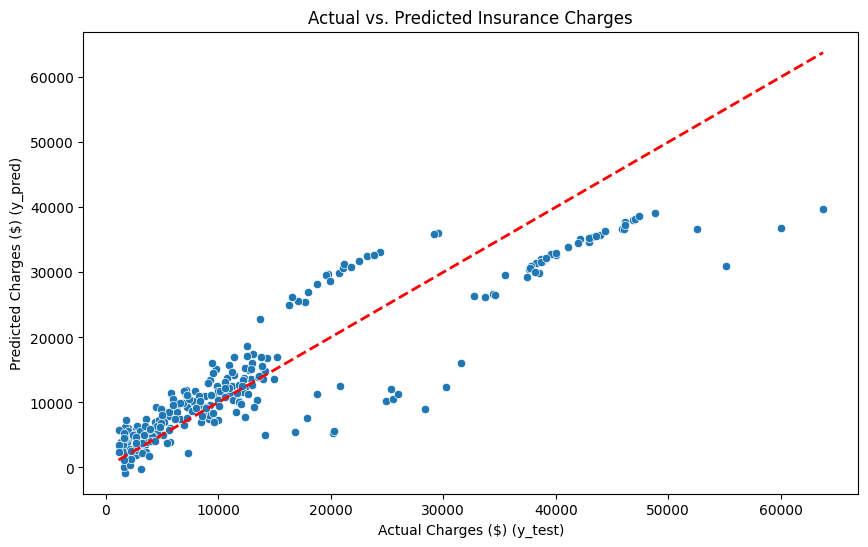

In [19]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Charges ($) (y_test)')
plt.ylabel('Predicted Charges ($) (y_pred)')
plt.title('Actual vs. Predicted Insurance Charges')


The "Actual vs. Predicted" scatterplot  also confirms this. The blue dots follow the red "perfect prediction" line very well for charges under $15,000, but they become much more spread out and inaccurate for the more expensive patients.

## ***Step 6: Interpretation & Inference***
**1.Summary of Major Findings**

My analysis of the insurance data provided two sets of major findings:

* **From the EDA (Step 3):** I discovered that the data for charges is highly right-skewed, meaning most people have low costs, but a few have extremely high costs. The Correlation Heatmap  showed that smoker status is by far the strongest predictor (0.79 correlation), followed by age (0.30) and bmi (0.20).

* **From the Modeling (Step 5):** My Linear Regression model achieved an $R^2$ of 0.8046 (or 80.46%). This means the features I used (smoker, age, bmi, etc.) successfully explain about 80% of the variation in insurance charges. The model's error metrics were an MAE of $4,198 (average error) and an RMSE of $5,991 (error with outliers punished). The large gap between MAE and RMSE confirms the model's main weakness is accurately predicting the high-cost outliers.



**2. Insights, Implications, and Significance**

* **Key Insight:** The most significant insight is that being a smoker is not just a factor; it is the dominant factor that controls the price. It doesn't just add a small fee; it fundamentally changes the cost structure, which was visible in the scatterplot where smokers' costs rose much faster with age.

* **Business Implications:** For an insurance company, this has clear and direct significance.

  * It provides a strong statistical justification for charging smokers significantly higher premiums.
  * The model, with its $R^2$ of 80.46%, is a good "baseline" tool for estimating quotes for new customers, but its $4,198 average error means it shouldn't be the only tool used.
  * The high RMSE ($5,991) warns the business that the model is unreliable for high-risk patients and should not be trusted for those cases.



**3. Reflection on the Analysis**

**1.What patterns or relationships did I identify?**

 * I identified three main patterns:

     *  A very strong, positive linear relationship between smoker status and charges.
     
     *  A moderate, positive linear relationship between age and charges.
     
     *  A weak, positive linear relationship between bmi and charges.The most complex pattern was the interaction effect between age and smoker status: the scatterplot  showed that the cost of aging is much steeper for smokers than for non-smokers.

**2.How did statistical testing validate my observations?** 

* The statistical test (Step 4) provided the proof for what my EDA plots showed.

    * My EDA boxplot  showed a difference between smokers and non-smokers.
    
    * The Independent T-Test validated this by giving a p-value of near-zero (e.g., 6.26x $10^-103$). This allowed me to reject the null hypothesis and prove, with 99.9% confidence, that this difference was not a random fluke.
    
    * The 95% Confidence Interval (e.g., [$22,190, $25,028]) further validated this by showing that the true difference is not $0 and is, in fact, a very large dollar amount.
    
**3.What could be improved with more data or features?**
 
* My model's 80.46% $R^2$ is good, but 19.54% of the cost is still unexplained. To improve, I would need:

    * **More Features:** This is the most important. The model struggles with high-cost outliers. Why are some non-smokers so expensive? I am missing key information. Adding features like pre-existing_conditions (e.g., diabetes, heart disease), chronic_illnesses, or even exercise_habits would almost certainly improve the model.
    
    * **A Better Model:** A simple Linear Regression model can't capture the complex "interaction" effect I saw. A more advanced, non-linear model (like a Random Forest or Gradient Boosting) would likely get a much higher $R^2$.
    
    * **Handle Skew:** The charges data was very skewed. By applying a log-transform to the charges variable before training, I could likely improve the Linear Regression model's stability and accuracy.

## ***Step 7: Visualization and Presentation***


**Description:** For this step, the most meaningful visualization is one that shows the performance of model. I created a scatterplot that directly compares the model's Predicted Charges (on the y-axis) against the Actual Charges (on the x-axis) from the 20% test set. This plot is the best way to "see" how good the model's $R^2$ score is in practice.

Text(0.5, 1.0, 'Actual vs. Predicted Insurance Charges')

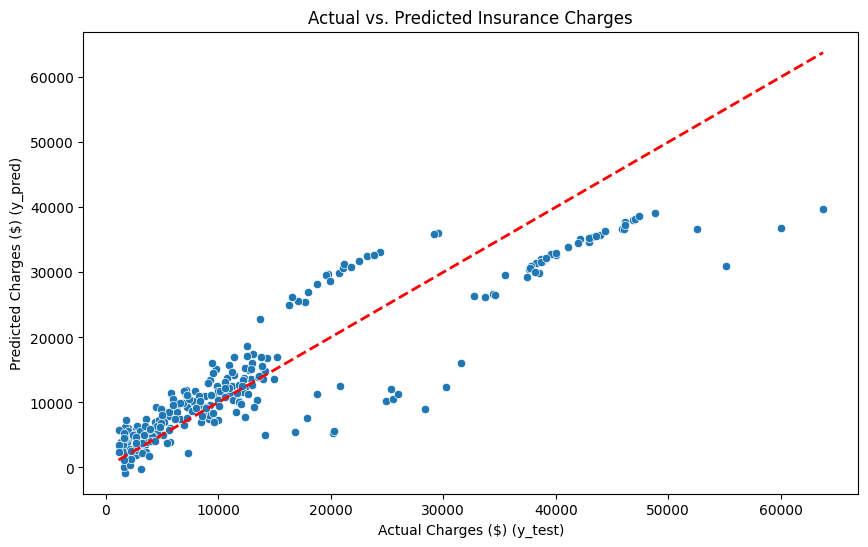

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test, y=y_pred)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Charges ($) (y_test)')
plt.ylabel('Predicted Charges ($) (y_pred)')
plt.title('Actual vs. Predicted Insurance Charges')

**Findings**

This plot shows how well the model's predictions (blue dots) match the real-world, actual charges (the y_test data). The red dashed line represents a "perfect" prediction, where the predicted value exactly equals the actual value.

As the plot shows, my model is very good at predicting charges for low-to-medium cost patients (the dots follow the red line closely in the $0 - $15,000 range). However, the plot also visually confirms the model's main weakness: for high-cost patients (the outliers), the predictions become much more spread out and less accurate. This is a visual representation of the high RMSE score we saw in Step 5.

## ***Step 8: Conclusion***

**1. Summary of Findings and Conclusions**
* This project successfully built a machine learning model to predict medical insurance charges. The Exploratory Data Analysis (EDA) revealed that the charges data was highly right-skewed, with most costs being low but a few being extremely high outliers.The most critical finding from the EDA was that smoker status is the dominant factor influencing price, with a strong positive correlation of 0.79. Age (0.30) and bmi (0.20) were also identified as secondary, but significant, predictors.Using these features, I trained a Linear Regression model. The model was evaluated on a 20% test set and achieved an $R^2$ of 0.8046. This concludes that my model can successfully explain 80.46% of the variability in insurance charges. The model's average error was an MAE of $4,198.11, though its higher RMSE of $5,991.82 indicates it struggles to accurately predict the very high-cost outlier patients.

**2. Limitations and Possible Future Improvements**

While the model is a good baseline, it has clear limitations and could be improved.

* **Limitations:** 
  * **Model Weakness:** The model's biggest weakness is its low accuracy for high-cost patients, as confirmed by the gap between MAE and RMSE.
  
  * **Data Skew:** The Linear Regression model was likely held back by the high skew of the charges data, which violates the model's assumption of normally distributed errors.
  
  * **Missing Features:** The model is "missing" key information. The 19.54% of unexplained variance is likely due to factors not included in the dataset, such as pre-existing conditions, chronic illnesses, or exercise habits.
  
* **Future Improvements:**
  
  * **Feature Engineering:** Apply a log-transform  to the charges variable. This would "un-skew" the data, making it more suitable for a Linear Regression model and likely improving its accuracy and stability.
  
  * **Add More Data:** The best way to improve the score would be to add features that explain why some non-smokers have high costs (e.g., a has_diabetes or has_heart_disease column).
  
  * **Use a Better Model:** A simple Linear Regression model can't capture the complex "interaction" effect we saw where age's impact is multiplied by smoking. A more advanced, non-linear model (like a Random Forest) would likely capture these patterns better and achieve a higher $R^2$.

**3. Key Takeaways**

This project demonstrated the full data analysis workflow. My initial data patterns (EDA) showed a massive visual difference in costs for smokers, which my statistical test (t-test) then proved was not a random fluke (p-value $\approx$ 0). Finally, my model results confirmed this by identifying smoker as the most powerful feature in a Linear Regression model that ultimately explained 80.46% of all price variations, solidifying that personal lifestyle choices (smoking) and demographics (age) are the primary drivers of medical costs. 